In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mplPath
from matplotlib import pyplot
import geopandas as gpd
import cartopy.io.shapereader as shpreader
import geodatasets
import xarray as xr
import numpy as np
from geopandas import GeoSeries
from pathlib import Path
from pyproj import Transformer
from shapely.geometry import Point , Polygon, MultiPolygon
from shapely.geometry.multipolygon import MultiPolygon
import shapely.wkt
import shapely.geometry
import shapely
from shapely.ops import nearest_points
from pathlib import Path
import rasterio
import rioxarray
import atlite

In [2]:
# Load precomputed 20-year capacity factors from the new source files.
# Downstream cells expect xr_resourcepotential with CF_Solar and CF_Wind on lat/lon coordinates.
solar_cf_path = Path(r"Data\capacityfactor_windsolar\pv_capacity_factor_25years_Grid0_1.nc")
wind_cf_path = Path(r"Data\capacityfactor_windsolar\wind_capacity_factor_25years_Grid0_1.nc")

pv_capacity_factor = xr.open_dataset(solar_cf_path)
wind_capacity_factor = xr.open_dataset(wind_cf_path)

xr_resourcepotential = xr.Dataset(
    data_vars={
        "CF_Solar": pv_capacity_factor["capacity_factor"],
        "CF_Wind": wind_capacity_factor["capacity_factor"],
    },
    attrs={
        "source_solar": str(solar_cf_path),
        "source_wind": str(wind_cf_path),
    },
)

print(xr_resourcepotential)


<xarray.Dataset> Size: 9kB
Dimensions:   (y: 30, x: 17)
Coordinates:
  * y         (y) float64 240B 5.7 6.2 6.7 7.2 7.7 ... 18.2 18.7 19.2 19.7 20.2
  * x         (x) float64 136B 97.4 97.9 98.4 98.9 ... 103.9 104.4 104.9 105.4
    lat       (y) float64 240B 5.7 6.2 6.7 7.2 7.7 ... 18.2 18.7 19.2 19.7 20.2
    lon       (x) float64 136B 97.4 97.9 98.4 98.9 ... 103.9 104.4 104.9 105.4
Data variables:
    CF_Solar  (y, x) float64 4kB ...
    CF_Wind   (y, x) float64 4kB ...
Attributes:
    source_solar:  Data\capacityfactor_windsolar\pv_capacity_factor_25years_G...
    source_wind:   Data\capacityfactor_windsolar\wind_capacity_factor_25years...


In [3]:
xr_landuse_suitability_index = xr.open_dataset('Output\\xr_SI_Landcover.nc')
df_landuse_suitability_index = xr_landuse_suitability_index.to_dataframe()
df_landuse_suitability_index.reset_index(inplace=True)
df_landuse_suitability_index = gpd.GeoDataFrame(df_landuse_suitability_index, geometry =gpd.points_from_xy(df_landuse_suitability_index['lon'],df_landuse_suitability_index['lat']))
df_landuse_suitability_index.crs = {'init': 'epsg:4326'}

df_resourcepotential = xr_resourcepotential.to_dataframe()
df_resourcepotential.reset_index(inplace=True)
df_resourcepotential = gpd.GeoDataFrame(df_resourcepotential, geometry =gpd.points_from_xy(df_resourcepotential['lon'],df_resourcepotential['lat']))
df_resourcepotential.crs = {'init': 'epsg:4326'}

df_resourcepotential_2 = gpd.sjoin_nearest(df_landuse_suitability_index,df_resourcepotential,how='left')

for i in df_resourcepotential_2.columns:
    if i not in (['lon_left','lat_left','lon','lat','CF_Wind','CF_Solar','geometry']):
        df_resourcepotential_2 = df_resourcepotential_2.drop(columns=i)

try: 
    df_resourcepotential_2 = df_resourcepotential_2.rename(columns= {'lon_left' : 'lon'})
    df_resourcepotential_2 = df_resourcepotential_2.rename(columns= {'lat_left' : 'lat'})
except:
    None

# ## Acquire polygon containing boudary of Thailand
# world_filepath = 'Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp'
# world = gpd.read_file(world_filepath)
# th = world.loc[world['name'] == 'Thailand'] # get Thailand row
# boundaries = th['geometry'] # get Thailand geometry
# boundaries.crs = {'init': 'epsg:4326'}
# boundaries = boundaries.geometry.unary_union

# # Load the detailed Thailand shapefile directly
# th_filepath = 'Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp'
# th = gpd.read_file(th_filepath)

# # This shapefile contains individual provinces. To get a single boundary for the whole country:
# boundaries = th.dissolve()


# df_resourcepotential_2['CF_Wind'].loc[~df_resourcepotential_2.within(boundaries)] = 0
# df_resourcepotential_2['CF_Solar'].loc[~df_resourcepotential_2.within(boundaries)] = 0

df_resourcepotential_2['CF_Wind'].loc[df_landuse_suitability_index['SI_Wind'] ==  0] = 0
df_resourcepotential_2['CF_Solar'].loc[df_landuse_suitability_index['SI_Solar'] ==  0] = 0

min_wind = df_resourcepotential_2['CF_Wind'].loc[df_resourcepotential_2['CF_Wind'] > 0].min()
max_wind = df_resourcepotential_2['CF_Wind'].loc[df_resourcepotential_2['CF_Wind'] > 0].max()

min_solar = df_resourcepotential_2['CF_Solar'].loc[df_resourcepotential_2['CF_Solar'] > 0 ].min()
max_solar = df_resourcepotential_2['CF_Solar'].loc[df_resourcepotential_2['CF_Solar'] > 0].max()

df_resourcepotential_2['CF_Wind'] = 3* (df_resourcepotential_2['CF_Wind']-min_wind)/(max_wind-min_wind)
df_resourcepotential_2['CF_Solar'] = 3* (df_resourcepotential_2['CF_Solar']-min_solar)/(max_solar-min_solar)

df_resourcepotential_2 = df_resourcepotential_2.rename(columns={'CF_Wind' : 'SI_Wind'})
df_resourcepotential_2 = df_resourcepotential_2.rename(columns={'CF_Solar' : 'SI_Solar'})


df_resourcepotential_2.reset_index(inplace=True,drop=True)

xr_landuse_suitability_index = xr.open_dataset('Output\\xr_SI_Landcover.nc')
df_landuse_suitability_index= xr_landuse_suitability_index.to_dataframe()
df_landuse_suitability_index.reset_index(inplace=True)
df_landuse_suitability_index = gpd.GeoDataFrame(df_landuse_suitability_index, geometry =gpd.points_from_xy(df_landuse_suitability_index['lon'],df_landuse_suitability_index['lat']))

# df_resourcepotential_2['SI_Wind'].loc[df_landuse_suitability_index['SI_Wind'] ==  0] = 0
# df_resourcepotential_2['SI_Solar'].loc[df_landuse_suitability_index['SI_Solar'] ==  0] = 0
df_resourcepotential_2.reset_index(inplace=True)

try: 
    df_resourcepotential_2 = df_resourcepotential_2.drop(columns=['geometry'])
except:
    None

print(df_resourcepotential_2.columns)
df_resourcepotential_2 = df_resourcepotential_2.groupby(['lat', 'lon']).agg('mean')
df_resourcepotential_2.reset_index(inplace=True)
df_resourcepotential_2 = df_resourcepotential_2.drop(columns = ['index'])
df_resourcepotential_2 = df_resourcepotential_2.set_index(['lat', 'lon'])
print(df_resourcepotential_2)

xr_resourcepotential_2 = xr.Dataset.from_dataframe(df_resourcepotential_2)
print(xr_resourcepotential_2)
xr_resourcepotential_2.to_netcdf(path='Output\\xr_SI_resourcepotential.nc')

d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
d:\workstation\RESITING\.env\Lib\site-packages\geopandas\array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geome

Index(['index', 'lat', 'lon', 'SI_Solar', 'SI_Wind'], dtype='object')
                       SI_Solar   SI_Wind
lat       lon                            
5.615278  97.345833  -42.315327 -0.040368
          97.348611  -42.315327 -0.040368
          97.351389  -42.315327 -0.040368
          97.354167  -42.315327 -0.040368
          97.356944  -42.315327 -0.040368
...                         ...       ...
20.462500 105.623611 -42.315327 -0.040368
          105.626389 -42.315327 -0.040368
          105.629167 -42.315327 -0.040368
          105.631944 -42.315327 -0.040368
          105.634722 -42.315327 -0.040368

[15957810 rows x 2 columns]
<xarray.Dataset> Size: 255MB
Dimensions:   (lat: 5346, lon: 2985)
Coordinates:
  * lat       (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon       (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_Solar  (lat, lon) float64 128MB -42.32 -42.32 -42.32 ... -42.32 -42.32
    SI_Wind   (lat, lon)

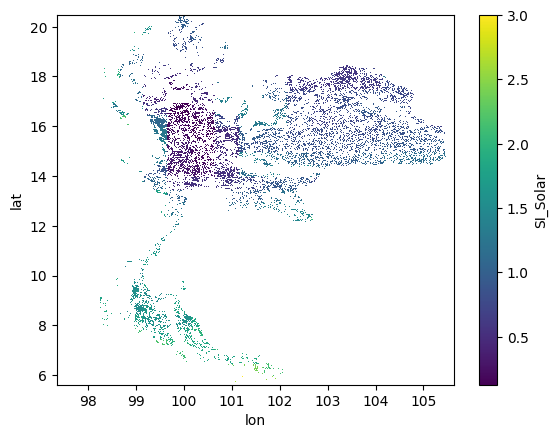

In [4]:
xr_resourcepotential_2['SI_Solar'].where(xr_resourcepotential_2['SI_Solar'] > 0).plot()

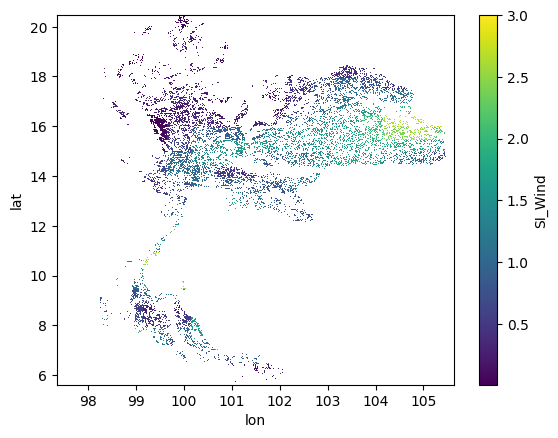

In [5]:
xr_resourcepotential_2['SI_Wind'].where(xr_resourcepotential_2['SI_Wind'] > 0).plot()